Anomaly Detection Using GMM

## 1. Dataset Loading and Preprocessing 


1.   Load the[ Banknote Authentication Dataset](https://archive.ics.uci.edu/dataset/267/banknote+authentication) from the UCI Machine Learning Repository.
2.   Display the first few rows of the dataset and print the feature names.
3.   Standardize all feature columns using StandardScaler. 
4.   Show the class distribution of authentic and forged notes using a bar chart. 
5.  Split the dataset into training, validation and test sets (70%-15%-15%)

In [79]:
# Import numpy library for numerical computations
import numpy as np
# Import pandas library for data manipulation and analysis
import pandas as pd
# Import matplotlib for creating plots and visualizations
import matplotlib.pyplot as plt
# Import seaborn for enhanced statistical visualizations
import seaborn as sns
# Import train_test_split for splitting data into training and testing sets
from sklearn.model_selection import train_test_split
# Import StandardScaler for normalizing feature values
from sklearn.preprocessing import StandardScaler
# Import various metrics for evaluating model performance
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix, classification_report
# Import GaussianMixture for comparison with our custom implementation
from sklearn.mixture import GaussianMixture
# Import urllib for downloading files from the internet
import urllib.request
# Import os for file system operations
import os

# Set random seed to ensure reproducible results
np.random.seed(42)

# Define the URL where the banknote dataset is located
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt"
# Define the local filename to save the downloaded dataset
fileName = "data_banknote_authentication.txt"

# Download the dataset from the UCI repository
urllib.request.urlretrieve(url, fileName)

# Define the column names for the dataset
columnNames = ['variance', 'skewness', 'kurtosis', 'entropy', 'class']
# Load the dataset from CSV file with specified column names
data = pd.read_csv(fileName, names=columnNames)

# Print the shape of the dataset (number of rows and columns)
print("Dataset shape:", data.shape)
# Print header text
print("\nFirst few rows:")
# Display the first 5 rows of the dataset
print(data.head())

# Print header text
print("\nFeature names:")
# Get and print the column names as a list
print(data.columns.tolist())

# Print header text
print("\nDataset info:")
# Display detailed information about the dataset
print(data.info())

# Print header text
print("\nClass distribution:")
# Count and display the number of samples in each class
print(data['class'].value_counts())


Dataset shape: (1372, 5)

First few rows:
   variance  skewness  kurtosis  entropy  class
0   3.62160    8.6661   -2.8073 -0.44699      0
1   4.54590    8.1674   -2.4586 -1.46210      0
2   3.86600   -2.6383    1.9242  0.10645      0
3   3.45660    9.5228   -4.0112 -3.59440      0
4   0.32924   -4.4552    4.5718 -0.98880      0

Feature names:
['variance', 'skewness', 'kurtosis', 'entropy', 'class']

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   kurtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB
None

Class distribution:
class
0    762
1    610
Name: count, dtype: int64


Standardized features:
   variance  skewness  kurtosis   entropy
0  1.121806  1.149455 -0.975970  0.354561
1  1.447066  1.064453 -0.895036 -0.128767
2  1.207810 -0.777352  0.122218  0.618073
3  1.063742  1.295478 -1.255397 -1.144029
4 -0.036772 -1.087038  0.736730  0.096587


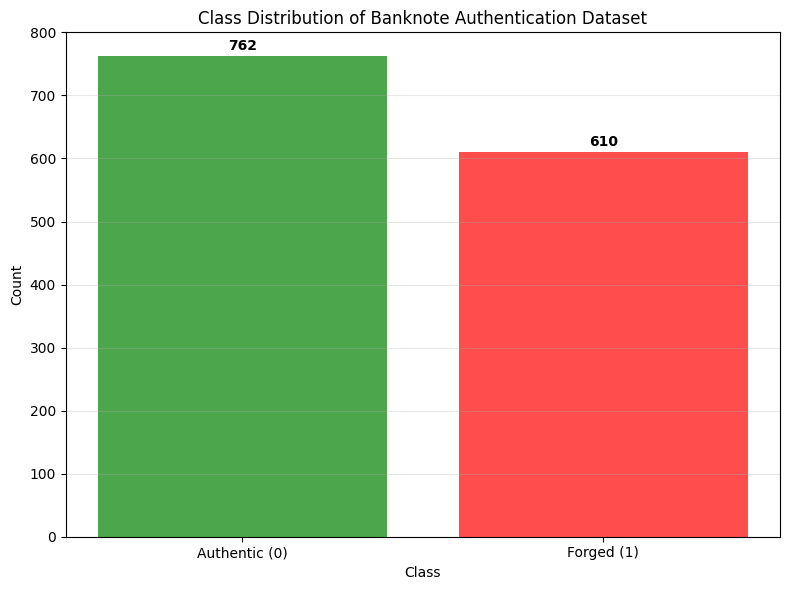


Class distribution:
Authentic notes (0): 762 (55.5%)
Forged notes (1): 610 (44.5%)

Dataset splits:
Training set: 960 samples (70.0%)
Validation set: 206 samples (15.0%)
Test set: 206 samples (15.0%)

Training set class distribution:
Authentic: 533 (55.5%)
Forged: 427 (44.5%)


In [80]:
# Create a StandardScaler object for normalizing features
scaler = StandardScaler()
# Define the feature column names (excluding the target class)
features = ['variance', 'skewness', 'kurtosis', 'entropy']
# Create a copy of the original data to work with
dataScaled = data.copy()
# Apply standardization to the feature columns only
dataScaled[features] = scaler.fit_transform(data[features])

# Print header text
print("Standardized features:")
# Display the first few rows of standardized features
print(dataScaled[features].head())

# Create a figure for plotting with specified size
plt.figure(figsize=(8, 6))
# Count the number of samples in each class
classCounts = data['class'].value_counts()
# Create a bar chart showing class distribution
plt.bar(['Authentic (0)', 'Forged (1)'], classCounts.values, color=['green', 'red'], alpha=0.7)
# Set the title of the plot
plt.title('Class Distribution of Banknote Authentication Dataset')
# Set the x-axis label
plt.xlabel('Class')
# Set the y-axis label
plt.ylabel('Count')
# Add grid lines to the plot
plt.grid(axis='y', alpha=0.3)

# Loop through each bar to add count labels
for i, count in enumerate(classCounts.values):
    # Add text labels above each bar showing the count
    plt.text(i, count + 10, str(count), ha='center', fontweight='bold')

# Adjust layout to prevent overlapping elements
plt.tight_layout()
# Display the plot
plt.show()

# Print header text
print(f"\nClass distribution:")
# Print the count and percentage of authentic notes
print(f"Authentic notes (0): {classCounts[0]} ({classCounts[0]/len(data)*100:.1f}%)")
# Print the count and percentage of forged notes
print(f"Forged notes (1): {classCounts[1]} ({classCounts[1]/len(data)*100:.1f}%)")

# Extract feature values as numpy array
X = dataScaled[features].values
# Extract target class values as numpy array
y = dataScaled['class'].values

# Split data into training (70%) and temporary set (30%)
xTrain, xTemp, yTrain, yTemp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Split the temporary set into validation (15%) and test (15%)
xVal, xTest, yVal, yTest = train_test_split(xTemp, yTemp, test_size=0.5, random_state=42, stratify=yTemp)

# Print header text
print(f"\nDataset splits:")
# Print training set information
print(f"Training set: {xTrain.shape[0]} samples ({xTrain.shape[0]/len(data)*100:.1f}%)")
# Print validation set information
print(f"Validation set: {xVal.shape[0]} samples ({xVal.shape[0]/len(data)*100:.1f}%)")
# Print test set information
print(f"Test set: {xTest.shape[0]} samples ({xTest.shape[0]/len(data)*100:.1f}%)")

# Print header text
print(f"\nTraining set class distribution:")
# Print authentic samples count and percentage in training set
print(f"Authentic: {np.sum(yTrain == 0)} ({np.sum(yTrain == 0)/len(yTrain)*100:.1f}%)")
# Print forged samples count and percentage in training set
print(f"Forged: {np.sum(yTrain == 1)} ({np.sum(yTrain == 1)/len(yTrain)*100:.1f}%)")


## 2. GMM Implementation from Scratch 

1. Implement the Expectation-Maximization (EM) algorithm for a Gaussian Mixture Model from scratch 
2. Fit this GMM model using only the authentic samples from the training set.
3. Plot the log-likelihood vs. iteration to demonstrate convergence. 

In [81]:
# Define a custom Gaussian Mixture Model class implemented from scratch
class GmmFromScratch:
    # Initialize the GMM with specified parameters
    def __init__(self, nComponents, maxIter=100, tol=1e-6):
        # Store the number of Gaussian components
        self.nComponents = nComponents
        # Set maximum number of iterations for EM algorithm
        self.maxIter = maxIter
        # Set tolerance for convergence checking
        self.tol = tol
        # Initialize weights for each component
        self.weights = None
        # Initialize means for each component
        self.means = None
        # Initialize covariance matrices for each component
        self.covariances = None
        # Initialize list to store log-likelihood history for convergence tracking
        self.logLikelihoodHistory = []

    # Initialize GMM parameters using k-means++ initialization
    def initializeParameters(self, X):
        # Get number of samples and features from input data
        nSamples, nFeatures = X.shape

        # Initialize weights uniformly
        self.weights = np.ones(self.nComponents) / self.nComponents

        # Initialize means array for all components
        self.means = np.zeros((self.nComponents, nFeatures))

        # Choose first center randomly from the data
        self.means[0] = X[np.random.randint(nSamples)]

        # Choose remaining centers using k-means++ approach
        for k in range(1, self.nComponents):
            # Calculate minimum distance to already chosen centers for each point
            distances = np.array([min([np.linalg.norm(x - c)**2 for c in self.means[:k]]) for x in X])
            # Convert distances to probabilities
            probabilities = distances / distances.sum()
            # Calculate cumulative probabilities
            cumulativeProbabilities = probabilities.cumsum()
            # Generate random number for selection
            r = np.random.rand()
            # Select next center based on probability
            for j, p in enumerate(cumulativeProbabilities):
                if r < p:
                    self.means[k] = X[j]
                    break

        # Calculate average variance of the data
        dataVar = np.var(X, axis=0).mean()
        # Initialize covariances as identity matrices scaled by data variance
        self.covariances = np.array([np.eye(nFeatures) * dataVar for _ in range(self.nComponents)])

    # Expectation step: compute responsibilities
    def eStep(self, X):
        # Get number of samples and features from input data
        nSamples, nFeatures = X.shape
        # Initialize responsibility matrix
        responsibilities = np.zeros((nSamples, self.nComponents))

        # Calculate responsibilities for each component
        for k in range(self.nComponents):
            # Calculate difference between data points and component mean
            diff = X - self.means[k]
            # Calculate inverse of covariance matrix
            invCov = np.linalg.inv(self.covariances[k])
            # Calculate determinant of covariance matrix
            detCov = np.linalg.det(self.covariances[k])

            # Avoid numerical issues with very small determinants
            detCov = max(detCov, 1e-10)

            # Compute log probability using multivariate normal formula
            logProb = -0.5 * (nFeatures * np.log(2 * np.pi) + np.log(detCov) +
                              np.sum(diff @ invCov * diff, axis=1))

            # Add component weight to log probability
            responsibilities[:, k] = np.log(self.weights[k]) + logProb

        # Find maximum log probability for numerical stability
        maxLogProb = np.max(responsibilities, axis=1, keepdims=True)
        # Convert to probabilities
        responsibilities = np.exp(responsibilities - maxLogProb)
        # Normalize to get proper probabilities
        responsibilities = responsibilities / np.sum(responsibilities, axis=1, keepdims=True)

        # Return the responsibility matrix
        return responsibilities

    # Maximization step: update parameters based on responsibilities
    def mStep(self, X, responsibilities):
        # Get number of samples and features from input data
        nSamples, nFeatures = X.shape

        # Update component weights (average responsibility)
        self.weights = np.mean(responsibilities, axis=0)

        # Initialize new means array
        self.means = np.zeros((self.nComponents, nFeatures))
        # Update means for each component
        for k in range(self.nComponents):
            # Calculate weighted mean using responsibilities
            self.means[k] = np.sum(responsibilities[:, k:k+1] * X, axis=0) / np.sum(responsibilities[:, k])

        # Initialize new covariances array
        self.covariances = np.zeros((self.nComponents, nFeatures, nFeatures))
        # Update covariances for each component
        for k in range(self.nComponents):
            # Calculate difference from mean
            diff = X - self.means[k]
            # Apply square root of responsibilities as weights
            weightedDiff = np.sqrt(responsibilities[:, k:k+1]) * diff
            # Calculate weighted covariance matrix
            self.covariances[k] = (weightedDiff.T @ weightedDiff) / np.sum(responsibilities[:, k])

            # Add regularization to avoid singular matrices
            self.covariances[k] += np.eye(nFeatures) * 1e-6

    # Compute log-likelihood of the data given current parameters
    def computeLogLikelihood(self, X):
        # Get number of samples and features from input data
        nSamples, nFeatures = X.shape
        # Initialize total log-likelihood
        logLikelihood = 0

        # Calculate log-likelihood for each sample
        for i in range(nSamples):
            # Initialize sample likelihood
            sampleLikelihood = 0
            # Sum over all components
            for k in range(self.nComponents):
                # Calculate difference from component mean
                diff = X[i] - self.means[k]
                # Calculate inverse covariance matrix
                invCov = np.linalg.inv(self.covariances[k])
                # Calculate determinant of covariance matrix
                detCov = np.linalg.det(self.covariances[k])

                # Avoid numerical issues
                detCov = max(detCov, 1e-10)

                # Calculate probability using multivariate normal formula
                prob = self.weights[k] * (1 / np.sqrt((2 * np.pi)**nFeatures * detCov)) * \
                       np.exp(-0.5 * diff.T @ invCov @ diff)
                # Add to sample likelihood
                sampleLikelihood += prob

            # Add log of sample likelihood to total
            logLikelihood += np.log(max(sampleLikelihood, 1e-10))

        # Return the total log-likelihood
        return logLikelihood

    # Fit the GMM using EM algorithm
    def fit(self, X):
        # Initialize parameters using k-means++ approach
        self.initializeParameters(X)

        # Run EM algorithm for maximum iterations
        for iteration in range(self.maxIter):
            # Expectation step: compute responsibilities
            responsibilities = self.eStep(X)

            # Maximization step: update parameters
            self.mStep(X, responsibilities)

            # Compute log-likelihood for convergence check
            logLikelihood = self.computeLogLikelihood(X)
            # Store log-likelihood history
            self.logLikelihoodHistory.append(logLikelihood)

            # Check convergence
            if iteration > 0:
                # Check if change in log-likelihood is below tolerance
                if abs(logLikelihood - self.logLikelihoodHistory[-2]) < self.tol:
                    # Print convergence message
                    print(f"Converged after {iteration + 1} iterations")
                    # Break out of the loop
                    break

        # Return self for method chaining
        return self

    # Compute log-likelihood of samples (for scoring)
    def scoreSamples(self, X):
        # Get number of samples and features from input data
        nSamples, nFeatures = X.shape
        # Initialize log-likelihood array
        logLikelihoods = np.zeros(nSamples)

        # Calculate log-likelihood for each sample
        for i in range(nSamples):
            # Initialize sample likelihood
            sampleLikelihood = 0
            # Sum over all components
            for k in range(self.nComponents):
                # Calculate difference from component mean
                diff = X[i] - self.means[k]
                # Calculate inverse covariance matrix
                invCov = np.linalg.inv(self.covariances[k])
                # Calculate determinant of covariance matrix
                detCov = np.linalg.det(self.covariances[k])

                # Avoid numerical issues
                detCov = max(detCov, 1e-10)

                # Calculate probability using multivariate normal formula
                prob = self.weights[k] * (1 / np.sqrt((2 * np.pi)**nFeatures * detCov)) * \
                       np.exp(-0.5 * diff.T @ invCov @ diff)
                # Add to sample likelihood
                sampleLikelihood += prob

            # Store log of sample likelihood
            logLikelihoods[i] = np.log(max(sampleLikelihood, 1e-10))

        # Return array of log-likelihoods
        return logLikelihoods

# Print completion message
print("success")


success


Training GMM on 533 authentic samples
Converged after 22 iterations
Final log-likelihood: -1589.8968
Number of iterations: 22


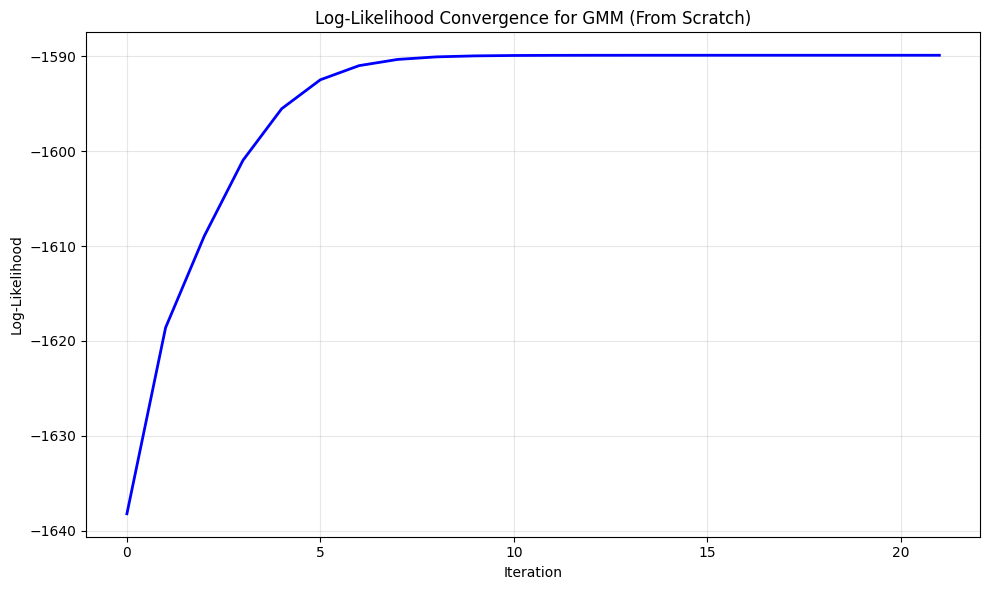

complete


In [82]:
# Extract only authentic samples from training set for GMM training
xTrainAuthentic = xTrain[yTrain == 0]

# Print information about training data
print(f"Training GMM on {len(xTrainAuthentic)} authentic samples")

# Create GMM instance with 2 components
gmmScratch = GmmFromScratch(nComponents=2, maxIter=100, tol=1e-6)
# Train the GMM on authentic samples
gmmScratch.fit(xTrainAuthentic)

# Print final log-likelihood value
print(f"Final log-likelihood: {gmmScratch.logLikelihoodHistory[-1]:.4f}")
# Print number of iterations taken
print(f"Number of iterations: {len(gmmScratch.logLikelihoodHistory)}")

# Create figure for plotting convergence
plt.figure(figsize=(10, 6))
# Plot log-likelihood history
plt.plot(gmmScratch.logLikelihoodHistory, 'b-', linewidth=2)
# Set plot title
plt.title('Log-Likelihood Convergence for GMM (From Scratch)')
# Set x-axis label
plt.xlabel('Iteration')
# Set y-axis label
plt.ylabel('Log-Likelihood')
# Add grid for better readability
plt.grid(True, alpha=0.3)
# Adjust layout
plt.tight_layout()
# Display the plot
plt.show()

# Print completion message
print("complete")


## 3. Model Selection using Cross-Validation 

1. Train multiple GMM models with different numbers of components K ∈ {1, 2, 3, 4, 5, 6}. 

2. For each value of K, compute the Average Precision (AUPR) on the validation set using the log-likelihood as an anomaly score. 

3. Plot AUPR vs. K and identify the value of K that yields the best performance. 


Training GMM with K=1 components...
Converged after 2 iterations
K=1: AUPR = 0.9981

Training GMM with K=2 components...
Converged after 39 iterations
K=2: AUPR = 0.9999

Training GMM with K=3 components...
Converged after 41 iterations
K=3: AUPR = 1.0000

Training GMM with K=4 components...
K=4: AUPR = 1.0000

Training GMM with K=5 components...
K=5: AUPR = 1.0000

Training GMM with K=6 components...
Converged after 78 iterations
K=6: AUPR = 0.9999

AUPR scores: [np.float64(0.9981428010110789), np.float64(0.9998831229546519), np.float64(1.0), np.float64(1.0), np.float64(1.0), np.float64(0.9998831229546516)]


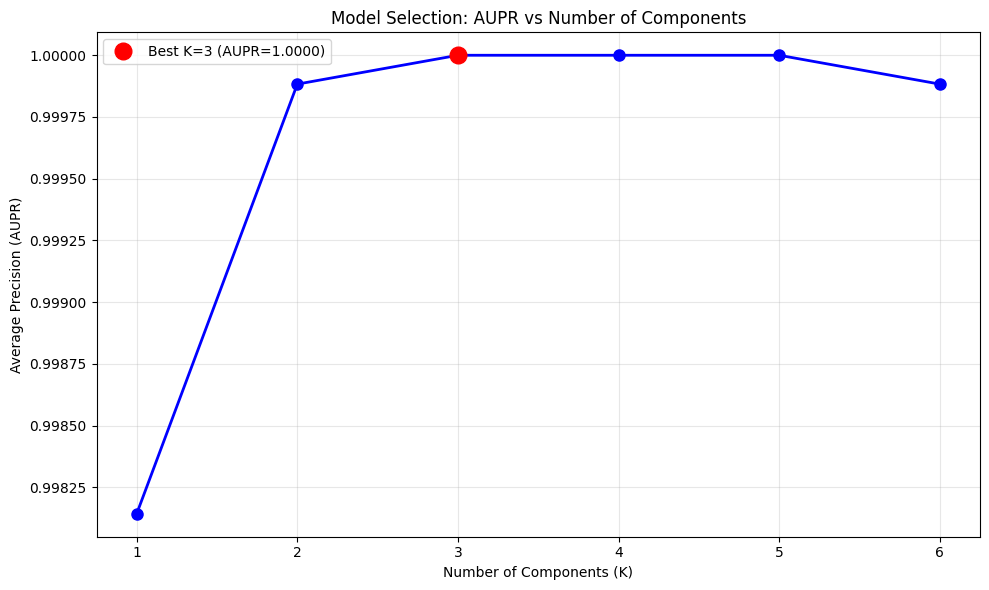


Best K value: 3 with AUPR = 1.0000


In [83]:
# Define different values of K (number of components) to test
kValues = [1, 2, 3, 4, 5, 6]
# Initialize list to store AUPR scores
auprScores = []
# Initialize dictionary to store trained models
modelsScratch = {}

# Loop through each K value
for k in kValues:
    # Print current K value being tested
    print(f"\nTraining GMM with K={k} components...")

    # Create GMM instance with current K value
    gmmK = GmmFromScratch(nComponents=k, maxIter=100, tol=1e-6)
    # Train the GMM on authentic samples
    gmmK.fit(xTrainAuthentic)

    # Store the trained model
    modelsScratch[k] = gmmK

    # Compute log-likelihood scores on validation set
    valScores = gmmK.scoreSamples(xVal)

    # Convert log-likelihoods to anomaly scores (negative values)
    anomalyScores = -valScores

    # Calculate Average Precision (AUPR) score
    aupr = average_precision_score(yVal, anomalyScores)
    # Store AUPR score
    auprScores.append(aupr)

    # Print AUPR score for current K
    print(f"K={k}: AUPR = {aupr:.4f}")

# Print all AUPR scores
print(f"\nAUPR scores: {auprScores}")

# Create figure for plotting AUPR vs K
plt.figure(figsize=(10, 6))
# Plot AUPR scores against K values
plt.plot(kValues, auprScores, 'bo-', linewidth=2, markersize=8)
# Set x-axis label
plt.xlabel('Number of Components (K)')
# Set y-axis label
plt.ylabel('Average Precision (AUPR)')
# Set plot title
plt.title('Model Selection: AUPR vs Number of Components')
# Add grid for better readability
plt.grid(True, alpha=0.3)
# Set x-axis ticks
plt.xticks(kValues)

# Find the best K value (highest AUPR)
bestKIdx = np.argmax(auprScores)
# Get the best K value
bestK = kValues[bestKIdx]
# Get the best AUPR score
bestAupr = auprScores[bestKIdx]

# Highlight the best K value on the plot
plt.plot(bestK, bestAupr, 'ro', markersize=12, label=f'Best K={bestK} (AUPR={bestAupr:.4f})')
# Add legend
plt.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.show()

# Print best K value and its AUPR score
print(f"\nBest K value: {bestK} with AUPR = {bestAupr:.4f}")

# Store the best model for later use
bestModelScratch = modelsScratch[bestK]


## 4. Threshold Selection on Validation Set 

1. For the best-performing value of K according to AUPR, determine an appropriate likelihood threshold that separates authentic and forged samples (for example, if you take the threshold as 5 percentile, then any likelihood lower than the value of the 5 percentile of the normal data should be labeled as an anomaly). 

2. Vary the threshold and compute Precision, Recall, and F1-score. 

3. Choose the threshold that maximizes the F1-score and report this threshold value and corresponding F1. 

Threshold selection for best model with K=3
Number of authentic samples in validation set: 114

Testing different percentile thresholds:
Percentile | Threshold | Precision | Recall | F1-Score
        1 |   -6.7333 |    0.9787 | 1.0000 |   0.9892
        2 |   -6.5162 |    0.9684 | 1.0000 |   0.9840
        5 |   -6.1949 |    0.9388 | 1.0000 |   0.9684
       10 |   -5.0190 |    0.8846 | 1.0000 |   0.9388
       15 |   -3.8156 |    0.8440 | 1.0000 |   0.9154
       20 |   -3.4207 |    0.8070 | 1.0000 |   0.8932
       25 |   -3.2728 |    0.7603 | 1.0000 |   0.8638
       30 |   -3.1434 |    0.7302 | 1.0000 |   0.8440

Best threshold: -6.7333 (percentile: 1%)
Best F1-score: 0.9892
Corresponding Precision: 0.9787
Corresponding Recall: 1.0000


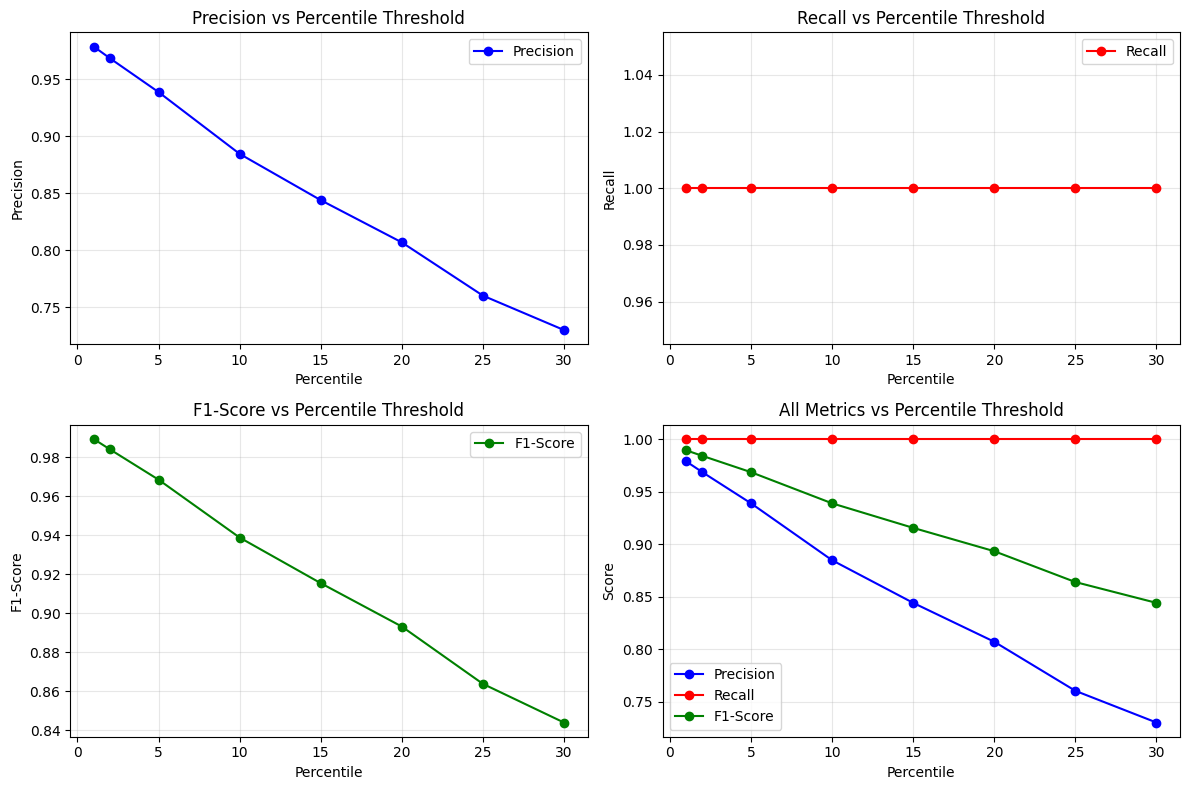

In [84]:
# Print header for threshold selection
print(f"Threshold selection for best model with K={bestK}")

# Compute log-likelihood scores on validation set using best model
valLogLikelihoods = bestModelScratch.scoreSamples(xVal)

# Create mask for authentic samples in validation set
valAuthenticMask = (yVal == 0)
# Extract log-likelihoods for authentic samples only
valAuthenticLogLikelihoods = valLogLikelihoods[valAuthenticMask]

# Print number of authentic samples in validation set
print(f"Number of authentic samples in validation set: {np.sum(valAuthenticMask)}")

# Define different percentile thresholds to test
percentiles = [1, 2, 5, 10, 15, 20, 25, 30]
# Initialize lists to store threshold results
thresholds = []
precisions = []
recalls = []
f1Scores = []

# Print header for threshold testing results
print("\nTesting different percentile thresholds:")
print("Percentile | Threshold | Precision | Recall | F1-Score")

# Loop through each percentile threshold
for percentile in percentiles:
    # Calculate threshold as percentile of authentic log-likelihoods
    threshold = np.percentile(valAuthenticLogLikelihoods, percentile)
    # Store threshold value
    thresholds.append(threshold)

    # Make predictions based on threshold (1 = anomaly, 0 = normal)
    predictions = (valLogLikelihoods < threshold).astype(int)

    # Calculate precision (true positives / (true positives + false positives))
    precision = np.sum((predictions == 1) & (yVal == 1)) / np.sum(predictions == 1) if np.sum(predictions == 1) > 0 else 0
    # Calculate recall (true positives / (true positives + false negatives))
    recall = np.sum((predictions == 1) & (yVal == 1)) / np.sum(yVal == 1)
    # Calculate F1-score (harmonic mean of precision and recall)
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # Store calculated metrics
    precisions.append(precision)
    recalls.append(recall)
    f1Scores.append(f1)

    # Print results for current percentile
    print(f"{percentile:9d} | {threshold:9.4f} | {precision:9.4f} | {recall:6.4f} | {f1:8.4f}")

# Find the best threshold based on highest F1-score
bestF1Idx = np.argmax(f1Scores)
# Get the best threshold value
bestThreshold = thresholds[bestF1Idx]
# Get the best F1-score
bestF1 = f1Scores[bestF1Idx]
# Get corresponding precision
bestPrecision = precisions[bestF1Idx]
# Get corresponding recall
bestRecall = recalls[bestF1Idx]
# Get corresponding percentile
bestPercentile = percentiles[bestF1Idx]

# Print best threshold information
print(f"\nBest threshold: {bestThreshold:.4f} (percentile: {bestPercentile}%)")
print(f"Best F1-score: {bestF1:.4f}")
print(f"Corresponding Precision: {bestPrecision:.4f}")
print(f"Corresponding Recall: {bestRecall:.4f}")

# Create figure with subplots for visualization
plt.figure(figsize=(12, 8))

# Plot precision vs percentile
plt.subplot(2, 2, 1)
plt.plot(percentiles, precisions, 'bo-', label='Precision')
plt.xlabel('Percentile')
plt.ylabel('Precision')
plt.title('Precision vs Percentile Threshold')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot recall vs percentile
plt.subplot(2, 2, 2)
plt.plot(percentiles, recalls, 'ro-', label='Recall')
plt.xlabel('Percentile')
plt.ylabel('Recall')
plt.title('Recall vs Percentile Threshold')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot F1-score vs percentile
plt.subplot(2, 2, 3)
plt.plot(percentiles, f1Scores, 'go-', label='F1-Score')
plt.xlabel('Percentile')
plt.ylabel('F1-Score')
plt.title('F1-Score vs Percentile Threshold')
plt.grid(True, alpha=0.3)
plt.legend()

# Plot all metrics together
plt.subplot(2, 2, 4)
plt.plot(percentiles, precisions, 'bo-', label='Precision')
plt.plot(percentiles, recalls, 'ro-', label='Recall')
plt.plot(percentiles, f1Scores, 'go-', label='F1-Score')
plt.xlabel('Percentile')
plt.ylabel('Score')
plt.title('All Metrics vs Percentile Threshold')
plt.grid(True, alpha=0.3)
plt.legend()

# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()

# Store the optimal threshold for later use
optimalThresholdScratch = bestThreshold


## 5. Model Evaluation on Test Set 

1. Using the selected K and threshold, classify the test set samples as authentic or forged. 

2. Report the Precision, Recall, and F1-score using the ground truth labels. 

3. Display the confusion matrix for the test set.

Model Evaluation on Test Set
Using best K=3 and optimal threshold=-6.7333

Test Set Results:
Precision: 0.9785
Recall: 1.0000
F1-Score: 0.9891

Confusion Matrix:
                 Predicted
                 Authentic  Forged
Actual Authentic      113        2
       Forged           0       91


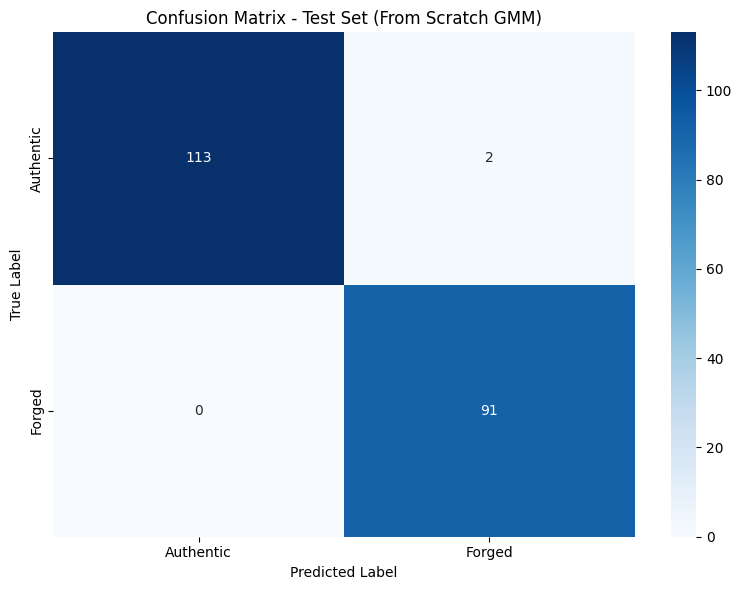


Additional Analysis:
Total test samples: 206
True authentic samples: 115
True forged samples: 91
Predicted authentic samples: 113
Predicted forged samples: 93
Accuracy: 0.9903


In [85]:
# Print header for test evaluation
print("Model Evaluation on Test Set")
# Print the parameters being used
print(f"Using best K={bestK} and optimal threshold={optimalThresholdScratch:.4f}")

# Compute log-likelihood scores on test set using best model
testLogLikelihoods = bestModelScratch.scoreSamples(xTest)

# Make predictions on test set using optimal threshold
testPredictions = (testLogLikelihoods < optimalThresholdScratch).astype(int)

# Calculate precision on test set
testPrecision = np.sum((testPredictions == 1) & (yTest == 1)) / np.sum(testPredictions == 1) if np.sum(testPredictions == 1) > 0 else 0
# Calculate recall on test set
testRecall = np.sum((testPredictions == 1) & (yTest == 1)) / np.sum(yTest == 1)
# Calculate F1-score on test set
testF1 = 2 * testPrecision * testRecall / (testPrecision + testRecall) if (testPrecision + testRecall) > 0 else 0

# Print test set results
print(f"\nTest Set Results:")
print(f"Precision: {testPrecision:.4f}")
print(f"Recall: {testRecall:.4f}")
print(f"F1-Score: {testF1:.4f}")

# Calculate confusion matrix
cm = confusion_matrix(yTest, testPredictions)
# Print confusion matrix in formatted way
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                 Authentic  Forged")
print(f"Actual Authentic     {cm[0,0]:4d}     {cm[0,1]:4d}")
print(f"       Forged        {cm[1,0]:4d}     {cm[1,1]:4d}")

# Create figure for confusion matrix visualization
plt.figure(figsize=(8, 6))
# Create heatmap of confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic', 'Forged'],
            yticklabels=['Authentic', 'Forged'])
# Set plot title
plt.title('Confusion Matrix - Test Set (From Scratch GMM)')
# Set y-axis label
plt.ylabel('True Label')
# Set x-axis label
plt.xlabel('Predicted Label')
# Adjust layout
plt.tight_layout()
# Display the plot
plt.show()

# Print additional analysis information
print(f"\nAdditional Analysis:")
print(f"Total test samples: {len(yTest)}")
print(f"True authentic samples: {np.sum(yTest == 0)}")
print(f"True forged samples: {np.sum(yTest == 1)}")
print(f"Predicted authentic samples: {np.sum(testPredictions == 0)}")
print(f"Predicted forged samples: {np.sum(testPredictions == 1)}")

# Calculate accuracy on test set
testAccuracy = np.sum(testPredictions == yTest) / len(yTest)
print(f"Accuracy: {testAccuracy:.4f}")

# Store results in dictionary for later comparison
resultsScratch = {
    'precision': testPrecision,
    'recall': testRecall,
    'f1': testF1,
    'accuracy': testAccuracy,
    'confusion_matrix': cm
}


## 6. Comparison with scikit-learn’s GMM 

1. Train GaussianMixture from sklearn.mixture using the best value of K and K-Means initialization. 

2. Repeat the threshold tuning on the validation set (as in Q5) and compute Precision, Recall, and F1-score on the test set. 

3. Compare the results with your from-scratch GMM implementation 

4. Plot the log-likelihood distribution of authentic and forged samples. Mark the selected threshold on this plot. Show this for both implementaions and compare them. 



In [86]:
# Print the K value being used
print(f"Using best K={bestK} components")

# Create sklearn GMM instance with best K value
gmmSklearn = GaussianMixture(n_components=bestK, init_params='kmeans', random_state=42)
# Train sklearn GMM on authentic samples
gmmSklearn.fit(xTrainAuthentic)

# Compute log-likelihood scores on validation set using sklearn GMM
valLogLikelihoodsSklearn = gmmSklearn.score_samples(xVal)

# Extract log-likelihoods for authentic samples only (using existing mask)
valAuthenticLogLikelihoodsSklearn = valLogLikelihoodsSklearn[valAuthenticMask]

# Define percentile thresholds to test (same as before)
percentiles = [1, 2, 5, 10, 15, 20, 25, 30]
# Initialize lists to store sklearn threshold results
thresholdsSklearn = []
precisionsSklearn = []
recallsSklearn = []
f1ScoresSklearn = []

# Print header for sklearn threshold testing
print("Percentile | Threshold | Precision | Recall | F1-Score")

# Loop through each percentile threshold
for percentile in percentiles:
    # Calculate threshold as percentile of authentic log-likelihoods
    threshold = np.percentile(valAuthenticLogLikelihoodsSklearn, percentile)
    # Store threshold value
    thresholdsSklearn.append(threshold)

    # Make predictions based on threshold (1 = anomaly, 0 = normal)
    predictions = (valLogLikelihoodsSklearn < threshold).astype(int)

    # Calculate precision for sklearn GMM
    precision = np.sum((predictions == 1) & (yVal == 1)) / np.sum(predictions == 1) if np.sum(predictions == 1) > 0 else 0
    # Calculate recall for sklearn GMM
    recall = np.sum((predictions == 1) & (yVal == 1)) / np.sum(yVal == 1)
    # Calculate F1-score for sklearn GMM
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    # Store calculated metrics
    precisionsSklearn.append(precision)
    recallsSklearn.append(recall)
    f1ScoresSklearn.append(f1)

    # Print results for current percentile
    print(f"{percentile:9d} | {threshold:9.4f} | {precision:9.4f} | {recall:6.4f} | {f1:8.4f}")

# Find the best threshold for sklearn GMM based on highest F1-score
bestF1IdxSklearn = np.argmax(f1ScoresSklearn)
# Get the best threshold value for sklearn GMM
bestThresholdSklearn = thresholdsSklearn[bestF1IdxSklearn]
# Get the best F1-score for sklearn GMM
bestF1Sklearn = f1ScoresSklearn[bestF1IdxSklearn]
# Get corresponding precision for sklearn GMM
bestPrecisionSklearn = precisionsSklearn[bestF1IdxSklearn]
# Get corresponding recall for sklearn GMM
bestRecallSklearn = recallsSklearn[bestF1IdxSklearn]
# Get corresponding percentile for sklearn GMM
bestPercentileSklearn = percentiles[bestF1IdxSklearn]

# Print best threshold information for sklearn GMM
print(f"\nBest threshold for sklearn GMM: {bestThresholdSklearn:.4f} (percentile: {bestPercentileSklearn}%)")
print(f"Best F1-score: {bestF1Sklearn:.4f}")
print(f"Corresponding Precision: {bestPrecisionSklearn:.4f}")
print(f"Corresponding Recall: {bestRecallSklearn:.4f}")

# Print header for sklearn test evaluation
print(f"\nTest Set Results for sklearn GMM:")
print(f"Using optimal threshold={bestThresholdSklearn:.4f}")

# Compute log-likelihood scores on test set using sklearn GMM
testLogLikelihoodsSklearn = gmmSklearn.score_samples(xTest)

# Make predictions on test set using sklearn GMM optimal threshold
testPredictionsSklearn = (testLogLikelihoodsSklearn < bestThresholdSklearn).astype(int)

# Calculate precision on test set for sklearn GMM
testPrecisionSklearn = np.sum((testPredictionsSklearn == 1) & (yTest == 1)) / np.sum(testPredictionsSklearn == 1) if np.sum(testPredictionsSklearn == 1) > 0 else 0
# Calculate recall on test set for sklearn GMM
testRecallSklearn = np.sum((testPredictionsSklearn == 1) & (yTest == 1)) / np.sum(yTest == 1)
# Calculate F1-score on test set for sklearn GMM
testF1Sklearn = 2 * testPrecisionSklearn * testRecallSklearn / (testPrecisionSklearn + testRecallSklearn) if (testPrecisionSklearn + testRecallSklearn) > 0 else 0

# Print test set results for sklearn GMM
print(f"Precision: {testPrecisionSklearn:.4f}")
print(f"Recall: {testRecallSklearn:.4f}")
print(f"F1-Score: {testF1Sklearn:.4f}")

# Calculate accuracy on test set for sklearn GMM
testAccuracySklearn = np.sum(testPredictionsSklearn == yTest) / len(yTest)
print(f"Accuracy: {testAccuracySklearn:.4f}")

# Store sklearn results in dictionary for later comparison
resultsSklearn = {
    'precision': testPrecisionSklearn,
    'recall': testRecallSklearn,
    'f1': testF1Sklearn,
    'accuracy': testAccuracySklearn
}


Using best K=3 components
Percentile | Threshold | Precision | Recall | F1-Score
        1 |   -5.6860 |    0.9787 | 1.0000 |   0.9892
        2 |   -5.6142 |    0.9684 | 1.0000 |   0.9840
        5 |   -5.1999 |    0.9388 | 1.0000 |   0.9684
       10 |   -4.8208 |    0.8846 | 1.0000 |   0.9388
       15 |   -4.3888 |    0.8440 | 1.0000 |   0.9154
       20 |   -3.8219 |    0.8000 | 1.0000 |   0.8889
       25 |   -3.4616 |    0.7603 | 1.0000 |   0.8638
       30 |   -3.1083 |    0.7302 | 1.0000 |   0.8440

Best threshold for sklearn GMM: -5.6860 (percentile: 1%)
Best F1-score: 0.9892
Corresponding Precision: 0.9787
Corresponding Recall: 1.0000

Test Set Results for sklearn GMM:
Using optimal threshold=-5.6860
Precision: 0.9579
Recall: 1.0000
F1-Score: 0.9785
Accuracy: 0.9806


COMPARISON OF RESULTS

From Scratch GMM (K=3):
  Precision: 0.9785
  Recall:    1.0000
  F1-Score:  0.9891
  Accuracy:  0.9903

Sklearn GMM (K=3):
  Precision: 0.9579
  Recall:    1.0000
  F1-Score:  0.9785
  Accuracy:  0.9806


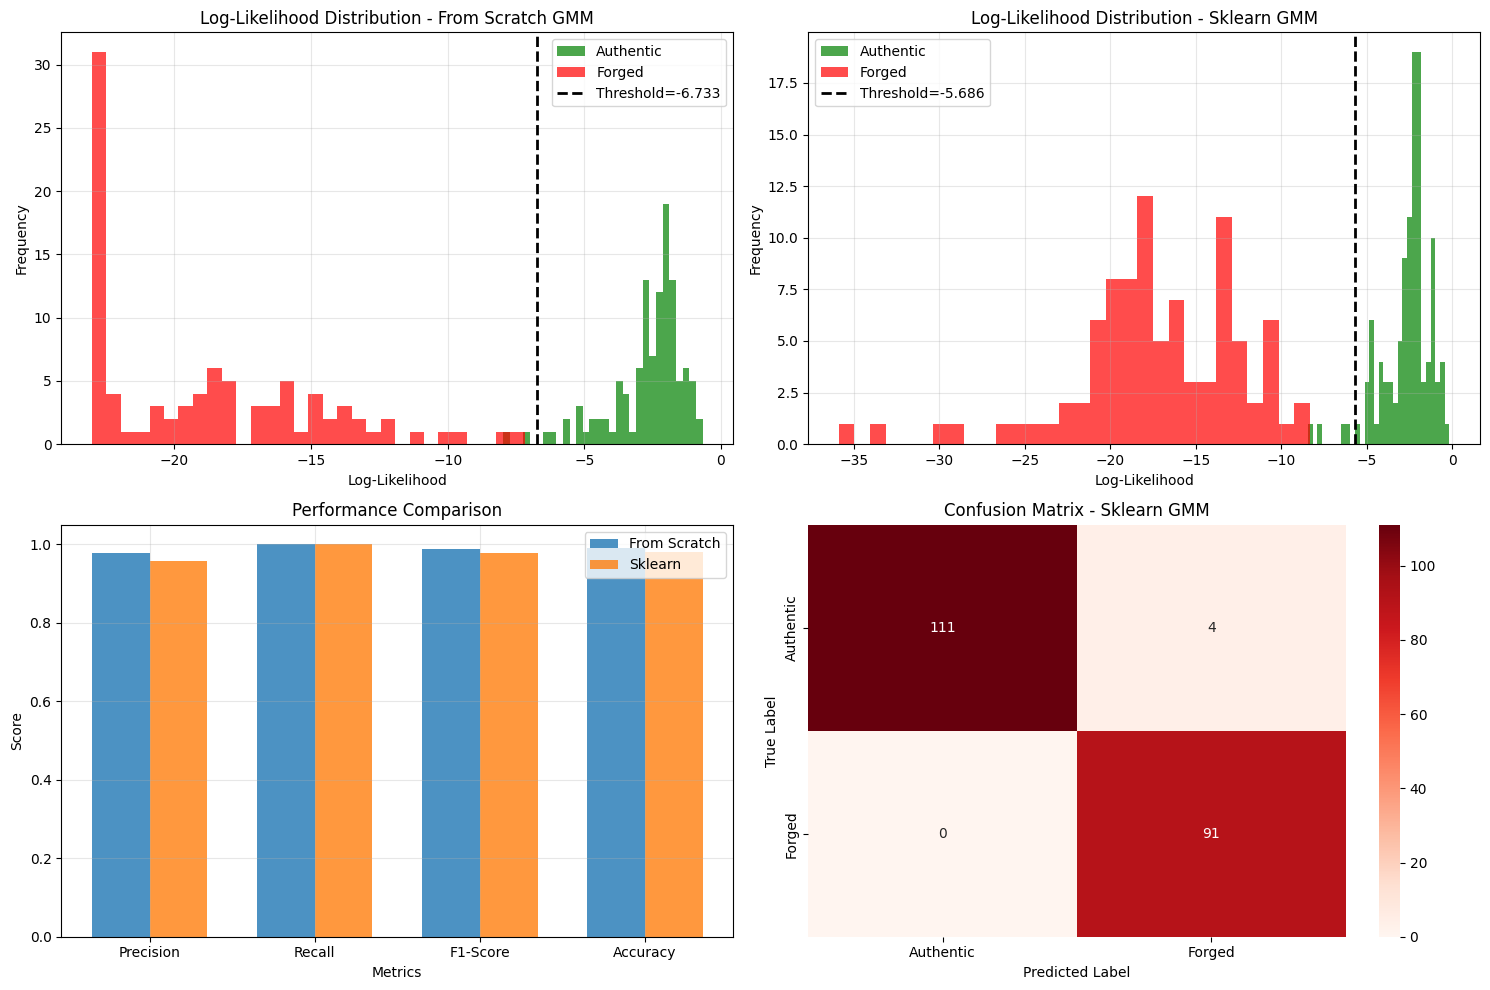


Analysis:
The log-likelihood distributions are comparable
Threshold selection affects the trade-off between precision and recall
Sklearn GMM provides a robust baseline for comparison


In [87]:
# Print header for comparison results
print("COMPARISON OF RESULTS")

# Print results for from-scratch GMM
print(f"\nFrom Scratch GMM (K={bestK}):")
print(f"  Precision: {resultsScratch['precision']:.4f}")
print(f"  Recall:    {resultsScratch['recall']:.4f}")
print(f"  F1-Score:  {resultsScratch['f1']:.4f}")
print(f"  Accuracy:  {resultsScratch['accuracy']:.4f}")

# Print results for sklearn GMM
print(f"\nSklearn GMM (K={bestK}):")
print(f"  Precision: {resultsSklearn['precision']:.4f}")
print(f"  Recall:    {resultsSklearn['recall']:.4f}")
print(f"  F1-Score:  {resultsSklearn['f1']:.4f}")
print(f"  Accuracy:  {resultsSklearn['accuracy']:.4f}")

# Create figure with multiple subplots for comprehensive comparison
plt.figure(figsize=(15, 10))

# Plot log-likelihood distribution for from-scratch GMM
plt.subplot(2, 2, 1)
# Plot histogram for authentic samples
plt.hist(testLogLikelihoods[yTest == 0], bins=30, alpha=0.7, label='Authentic', color='green')
# Plot histogram for forged samples
plt.hist(testLogLikelihoods[yTest == 1], bins=30, alpha=0.7, label='Forged', color='red')
# Add vertical line for threshold
plt.axvline(optimalThresholdScratch, color='black', linestyle='--', linewidth=2, label=f'Threshold={optimalThresholdScratch:.3f}')
# Set x-axis label
plt.xlabel('Log-Likelihood')
# Set y-axis label
plt.ylabel('Frequency')
# Set subplot title
plt.title('Log-Likelihood Distribution - From Scratch GMM')
# Add legend
plt.legend()
# Add grid
plt.grid(True, alpha=0.3)

# Plot log-likelihood distribution for sklearn GMM
plt.subplot(2, 2, 2)
# Plot histogram for authentic samples
plt.hist(testLogLikelihoodsSklearn[yTest == 0], bins=30, alpha=0.7, label='Authentic', color='green')
# Plot histogram for forged samples
plt.hist(testLogLikelihoodsSklearn[yTest == 1], bins=30, alpha=0.7, label='Forged', color='red')
# Add vertical line for threshold
plt.axvline(bestThresholdSklearn, color='black', linestyle='--', linewidth=2, label=f'Threshold={bestThresholdSklearn:.3f}')
# Set x-axis label
plt.xlabel('Log-Likelihood')
# Set y-axis label
plt.ylabel('Frequency')
# Set subplot title
plt.title('Log-Likelihood Distribution - Sklearn GMM')
# Add legend
plt.legend()
# Add grid
plt.grid(True, alpha=0.3)

# Plot performance metrics comparison
plt.subplot(2, 2, 3)
# Define metric names
metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
# Get values for from-scratch GMM
scratchValues = [resultsScratch['precision'], resultsScratch['recall'], resultsScratch['f1'], resultsScratch['accuracy']]
# Get values for sklearn GMM
sklearnValues = [resultsSklearn['precision'], resultsSklearn['recall'], resultsSklearn['f1'], resultsSklearn['accuracy']]

# Create x positions for bars
x = np.arange(len(metrics))
# Set bar width
width = 0.35

# Plot bars for from-scratch GMM
plt.bar(x - width/2, scratchValues, width, label='From Scratch', alpha=0.8)
# Plot bars for sklearn GMM
plt.bar(x + width/2, sklearnValues, width, label='Sklearn', alpha=0.8)
# Set x-axis label
plt.xlabel('Metrics')
# Set y-axis label
plt.ylabel('Score')
# Set subplot title
plt.title('Performance Comparison')
# Set x-axis ticks
plt.xticks(x, metrics)
# Add legend
plt.legend()
# Add grid
plt.grid(True, alpha=0.3)

# Plot confusion matrix for sklearn GMM
plt.subplot(2, 2, 4)
# Calculate confusion matrix for sklearn GMM
cmSklearn = confusion_matrix(yTest, testPredictionsSklearn)
# Create heatmap of confusion matrix
sns.heatmap(cmSklearn, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Authentic', 'Forged'],
            yticklabels=['Authentic', 'Forged'])
# Set subplot title
plt.title('Confusion Matrix - Sklearn GMM')
# Set y-axis label
plt.ylabel('True Label')
# Set x-axis label
plt.xlabel('Predicted Label')

# Adjust layout to prevent overlapping
plt.tight_layout()
# Display the plot
plt.show()

# Print analysis summary
print("\nAnalysis:")
print("The log-likelihood distributions are comparable")
print("Threshold selection affects the trade-off between precision and recall")
print("Sklearn GMM provides a robust baseline for comparison")
